<a href="https://colab.research.google.com/github/leo-aguiar/ibm_hr_analytics_employee/blob/main/IBM_Analytics_Employee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Bibliotecas para manipulação, visualização e ingestão de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kagg
import os

In [2]:
# Realiza a ingestão do dataset diretamente do Kaggle para o ambiente local
path = kagg.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.


In [3]:
# Carrega o dataset de rotatividade de funcionários em um DataFrame para posterior análise exploratória e modelagem
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv"))

In [4]:
# Seleciona amostra aleatória de registros para inspeção inicial dos dados
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1355,36,No,Travel_Rarely,335,Sales,17,2,Marketing,1,1908,...,3,80,2,12,1,1,4,2,1,3
1446,34,No,Travel_Rarely,704,Sales,28,3,Marketing,1,2035,...,4,80,2,8,2,3,8,7,1,7
1406,54,No,Travel_Rarely,157,Research & Development,10,3,Medical,1,1980,...,4,80,0,9,3,3,5,2,1,4
689,20,Yes,Travel_Rarely,129,Research & Development,4,3,Technical Degree,1,960,...,2,80,0,1,2,3,1,0,0,0
315,43,No,Travel_Frequently,185,Research & Development,10,4,Life Sciences,1,430,...,1,80,0,9,5,3,8,7,1,7


In [5]:
# Inspeciona a estrutura geral do dataset para avaliar volume de registros, tipos de dados, completude das colunas e possíveis necessidades de pré-processamento
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Avalia a completude do dataset ao consolidar, por coluna,
# a quantidade absoluta e percentual de valores ausentes por vaariável
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
})
missing_table = missing_table.sort_values(by='Missing %', ascending=False)
missing_table

,Missing Count,Missing %
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


In [7]:
# Annotation: Não foram identificados valores ausentes no dataset, indicando completude total das variáveis e eliminando a necessidade de tartamento de missinbg values nesta etapa do pré-processamento.

In [8]:
# Segmenta as variáveis conforme seu tipo de dado para direcionar análises específicas de atributos numéricos e categóricos
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

In [9]:
numerical_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [10]:
categorical_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [11]:
# Variáveis categóricas ordinais codificadas numericamente
ordinal_cols = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

In [12]:
# Exclui features ordinais da lista numérica por representarem categorias ordenadas, não valores contínuos
numerical_cols = [
    col for col in numerical_cols
    if col not in ordinal_cols
]

In [13]:
numerical_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'EmployeeCount',
 'EmployeeNumber',
 'HourlyRate',
 'JobLevel',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [14]:
# Analisa a distribuição da variável alvo para compreender a taxa de attrition e avaliar o balanceamento entre as classes do problema
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [15]:
# Analisa a distribuição da variável alvo para compreender a taxa de attrition e avaliar o balanceamento entre as classes do problema
target_table = pd.DataFrame({
    'Contagem': df['Attrition'].value_counts(),
    'Taxa (%)': (df['Attrition'].value_counts(normalize=True) * 100).round(2)
})
target_table

,Contagem,Taxa (%)
Attrition,,
No,1233,83.88
Yes,237,16.12


In [16]:
# Annotation: A variável alvo apresenta desbalanceamento moderado, com predominância da classe negativa, o que deverá ser considerado nas etapas de modelagem e avaliação de performance

In [17]:
# Gera estatísticas descritivas das variáveis numéricas para avaliar distribuição, tendência central, dispersão e possíveis valores extremos
numerical_summary = df[numerical_cols].describe().T
numerical_summary

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.00,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0


In [18]:
# Annotation: As colunas EmployeeCount e EmployeeCount não carregam informação útil para análise/modelagem, portanto podem ser removidas

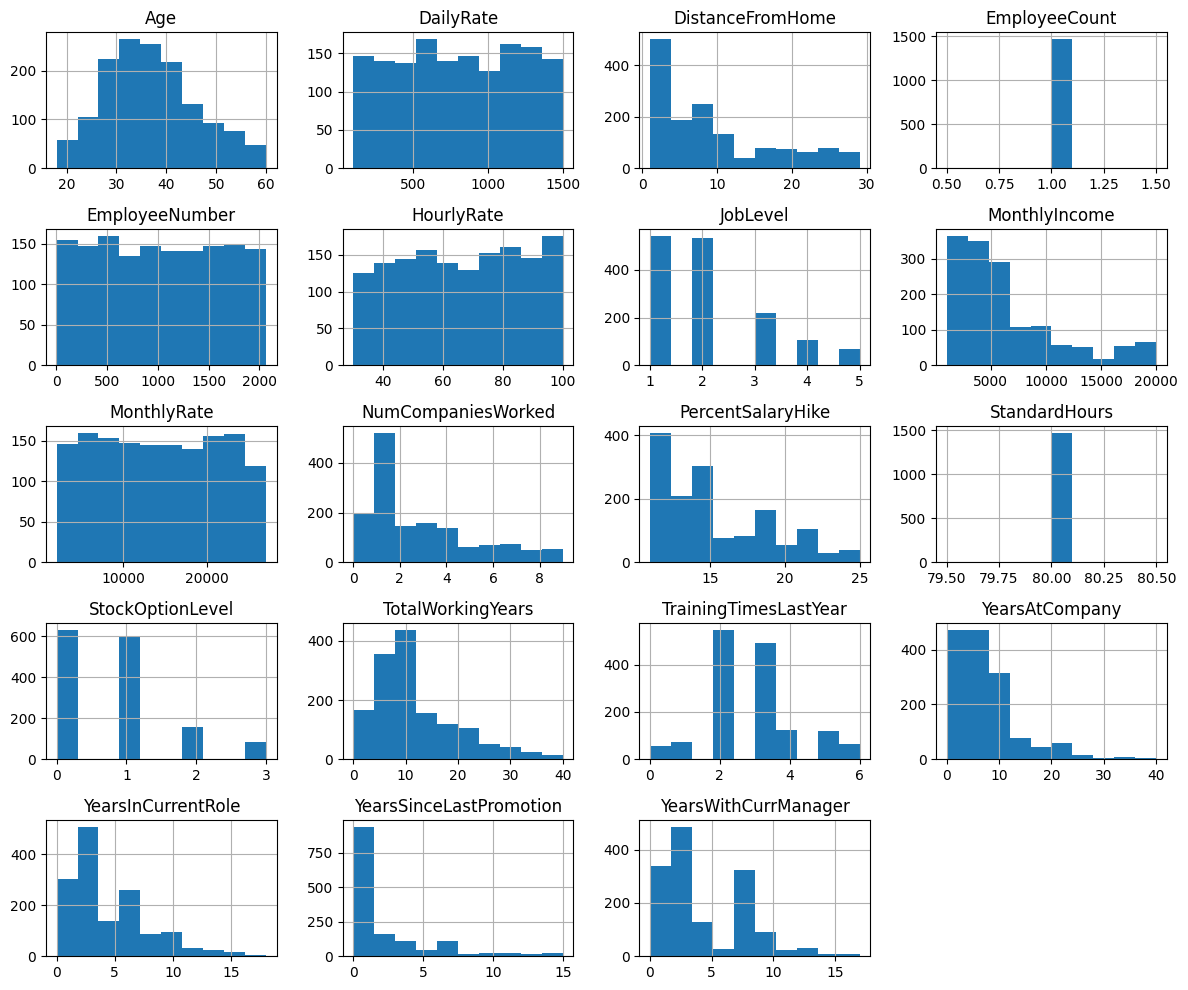

In [19]:
# Visualiza a distribuição das variáveis numéricas para identificar padrões, assimetrias e possíveis valores extremos
df[numerical_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

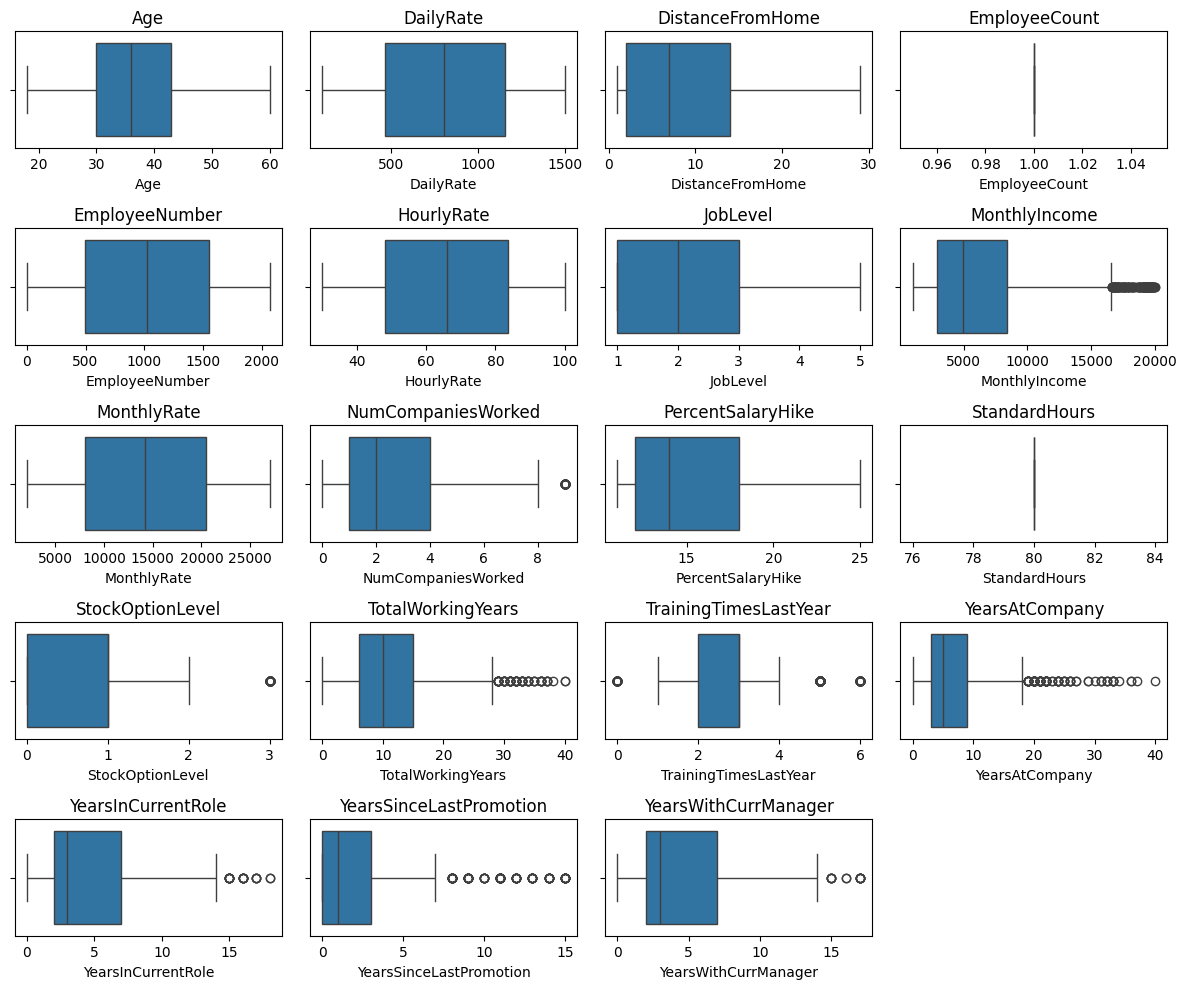

In [20]:
# Analisa a dispersão das variáveis numéricas para identificar possíveis outliers e padrões de distribuição dos dados
plt.figure(figsize=(12, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
# Analisa a relação entre realização de horas extras e taxa de attrition para investigar possível impacto da carga de trabalho na rotatividade
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [22]:
# Funcionários que realizam horas extras apresentam taxa de attrition significativamente superior aos que não realizam overtime (3x mais aproximadamente), sugerindo possível impacto da sobrecarga de trabalho na retenção.

In [23]:
# Analisa a relação entre nível de satisfação no trabalho e taxa de attrition para investigar possível impacto da satisfação na retenção de funcionários
jobsat_attrition = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

jobsat_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [24]:
# Observa-se uma relação inversa entre satisfação no trabalho e attrition, indicando que funcionários menos satisfeitos apresentam maiores taxas de saída da empresa

# A relação não é perfeitamente linear

In [25]:
# Analisa a relação entre equilíbrio vida-trabalho e taxa de attrition para investigar possível impacto do bem-estar na retenção de funcionários

worklife_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

worklife_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [26]:
# Funcionários com pior equilíbrio entre vida pessoal e trabalho (nível 1) apresentam taxa de attrition significativamente superior aos demais grupos. Entretanto, não foi observada uma relação linear entre os níveis subsequentes da variável, sugerindo que o principal fator de risco está associado a percepções muito negativas de equilíbrio vida-trabalho.

In [27]:
# Analisa a quantidade de funcionários em cada nível de WorkLifeBalance
df['WorkLifeBalance'].value_counts().sort_index()

,count
WorkLifeBalance,
1,80
2,344
3,893
4,153


In [28]:
# Há evidências de que funcionários com pior equilíbrio entre vida pessoal e trabalho apresentam maior propensão à saída da empresa.

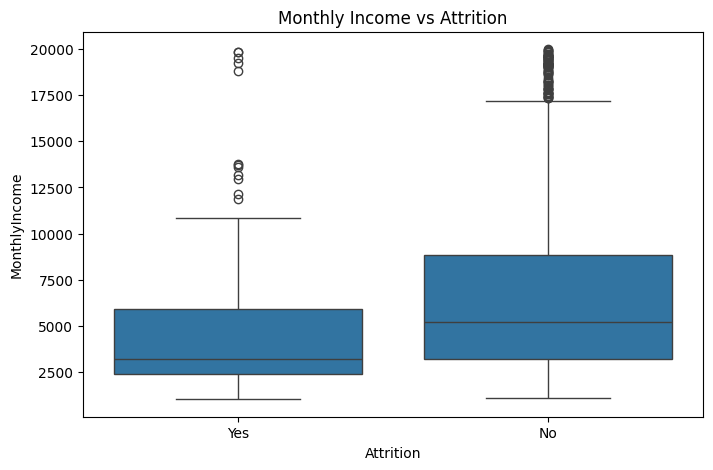

In [29]:
# Compara a distribuição salarial entre funcionários que permaneceram e os que deixaram a empresa para investigar possível relação entre renda e attrition
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title('Monthly Income vs Attrition')
plt.show()

In [30]:
# Os funcionários que permaneceram na empresa apresentam renda mensal superior aos que deixaram a organização. A mediana salarial do grupo sem attrition é significativamente maior, sugerindo uma associação entre remuneração e retenção de talentos.

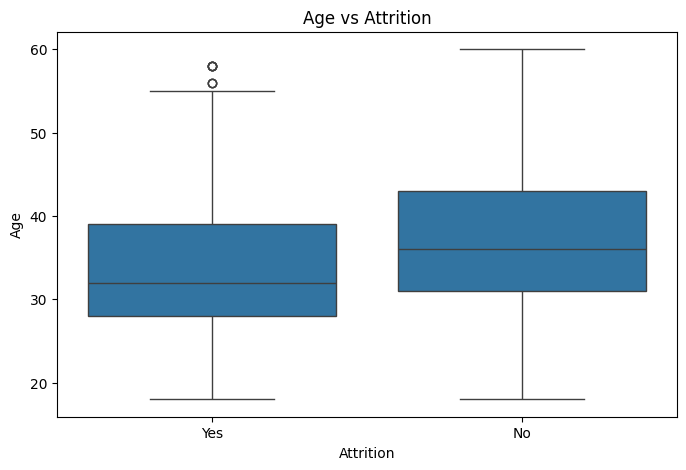

In [31]:
# Compara a distribuição de idade entre funcionários que permaneceram e os que deixaram a empresa para investigar possível relação entre faixa etária e attrition
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Attrition',
    y='Age',
    data=df
)

plt.title('Age vs Attrition')
plt.show()

In [32]:
# Funcionários que deixaram a empresa apresentam idade inferior aos que permaneceram. A distribuição etária do grupo com attrition encontra-se deslocada para faixas mais jovens, sugerindo associação entre menor idade e maior propensão à saída da organização.

In [33]:
# Verifica a distribuição da variável Over18 para avaliar sua variabilidade e relevância analítica
df['Over18'].value_counts()

,count
Over18,
Y,1470


In [34]:
# A variável Over18 apresenta apenas uma categoria (Y) em todos os registros, não contribuindo para a discriminação entre observações e sendo candidata à remoção em etapas posteriores de preparação dos dados.